In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT uid, timestamp
FROM checker
WHERE uid NOT LIKE 'admin%';
"""

df = pd.read_sql(query, connection, parse_dates=['timestamp'])

In [4]:
df['dayofweek'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour

In [5]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['dayofweek'] = pd.Categorical(df['dayofweek'], categories=days_order, ordered=True)

In [6]:
df_day_grouped = df.groupby(['uid', 'dayofweek'], observed=False).count()
df_day_heatmap = df_day_grouped.pivot_table(index='dayofweek', columns='uid', values='timestamp', fill_value=0, observed=False)
df_day_heatmap

uid,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_7,user_8
dayofweek,,,,,,,,,,,,,,,,,,,,,
Monday,3.0,0.0,0.0,0.0,2.0,3.0,50.0,0.0,10.0,8.0,...,0.0,0.0,9.0,46.0,2.0,5.0,35.0,1.0,0.0,0.0
Tuesday,0.0,0.0,16.0,0.0,1.0,57.0,87.0,0.0,5.0,4.0,...,0.0,7.0,26.0,11.0,3.0,0.0,86.0,0.0,5.0,0.0
Wednesday,0.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,44.0,32.0,0.0,1.0,0.0,33.0,4.0,3.0,0.0
Thursday,0.0,39.0,77.0,0.0,7.0,4.0,17.0,5.0,14.0,17.0,...,15.0,12.0,25.0,7.0,20.0,7.0,108.0,2.0,0.0,15.0
Friday,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7.0,1.0,59.0,3.0,35.0,61.0,0.0,0.0,0.0
Saturday,0.0,1.0,4.0,0.0,7.0,28.0,79.0,4.0,0.0,32.0,...,0.0,12.0,2.0,3.0,22.0,90.0,0.0,2.0,0.0,46.0
Sunday,0.0,43.0,2.0,8.0,76.0,23.0,26.0,20.0,31.0,0.0,...,27.0,32.0,26.0,8.0,21.0,7.0,45.0,9.0,0.0,26.0


In [7]:
df_day_heatmap = df_day_heatmap[df_day_heatmap.sum().sort_values(ascending=False).index]

In [8]:
df_hour_grouped = df.groupby(['uid', 'hour'], observed=False).count()
df_hour_heatmap = df_hour_grouped.pivot_table(index='hour', columns='uid', values='timestamp', fill_value=0, observed=False)
df_hour_heatmap = df_hour_heatmap[df_hour_heatmap.sum().sort_values(ascending=False).index]
df_hour_heatmap

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.0,4.0,13.0,0.0,0.0,3.0,0.0,1.0,0.0,3.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0
10,26.0,2.0,42.0,18.0,20.0,16.0,0.0,0.0,0.0,2.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


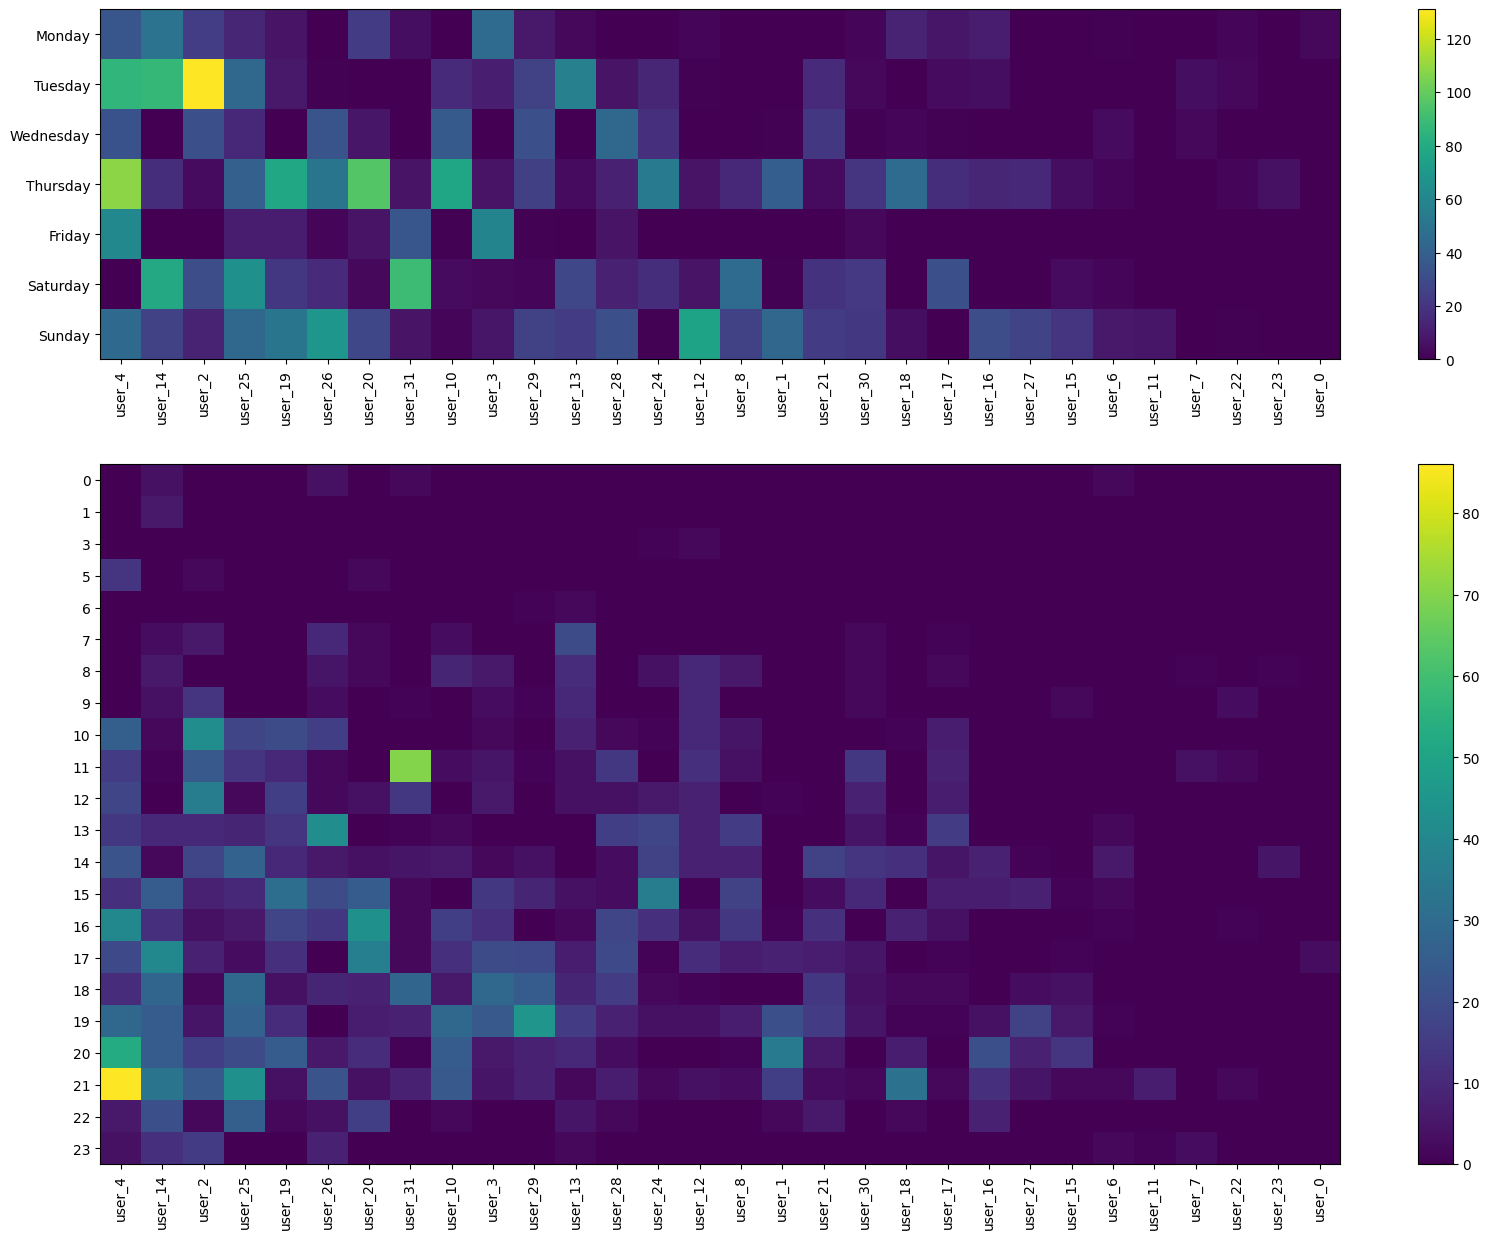

In [9]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(20, 15), gridspec_kw={'height_ratios': [1, 2]}) 
# gridspec holds ax0, ax1 proportion

heatmap1 = ax0.imshow(df_day_heatmap, cmap="viridis", aspect="auto")

ax0.set_xticks(range(len(df_day_heatmap.columns)))
ax0.set_xticklabels(df_day_heatmap.columns, rotation=90)
ax0.set_yticks(range(len(days_order)))
ax0.set_yticklabels(days_order)

cbar1 = plt.colorbar(heatmap1)

heatmap2 = ax1.imshow(df_hour_heatmap, cmap="viridis", aspect="auto")

ax1.set_xticks(range(len(df_hour_heatmap.columns)))
ax1.set_xticklabels(df_hour_heatmap.columns, rotation=90)
ax1.set_yticks(range(len(df_hour_heatmap.index)))
ax1.set_yticklabels(df_hour_heatmap.index)

# cax2 = ax_divider.append_axes("right", size="5%", pad="1%")
cbar2 = plt.colorbar(heatmap2)

plt.show()

In [10]:
connection.close()

## «У какого пользователя больше всего коммитов во Вт?» 

Ответ: user_2.


## «У какого пользователя больше всего коммитов в Чт?» 

Ответ: user_4.

## «В какой будний день пользователи не любят делать много коммитов?» 

Ответ: пятница

## «Какой пользователь в какой час сделал наибольшее количество коммитов?» 
Ответ, например: user_4, 21